In [33]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [34]:
with open('MATRIZ_C.pickle', 'rb') as infile:
    MATRIZ = pickle.load(infile)
    MATRIZ = np.array(MATRIZ)

In [35]:
# MATRIZ = np.array([
#     [2, 3, 1, 3, 1, 2],
#     [3, 3, 2, 1, 2, 3],
#     [1, 2, 3, 2, 3, 1],
#     [3, 1, 2, 2, 3, 3],
#     [1, 2, 3, 2, 3, 1],
#     [2, 3, 1, 1, 2, 3]
# ])

numberToLetter = {
    1: "C",
    2: "Q",
    3: "T"
}

direcoes = [
    (-1, 0),
    (-1, 1),
    (0, 1),
    (1, 1),
    (1, 0),
    (1, -1),
    (0, -1),
    (-1, -1)
]

direcoes_quadrado = [
    (0, 1),
    (1, 0)
]

direcoes_diagonais = [
    (-1, -1),
    (-1, 1),
    (1, -1),
    (1, 1)
]

arestas = []
visitados = set()

In [36]:
G = nx.DiGraph()

pos = {
    (linha, coluna): (coluna, -linha)
    for linha in range(MATRIZ.shape[0])
    for coluna in range(MATRIZ.shape[1])
}

for linha in range(MATRIZ.shape[0]):
    for coluna in range(MATRIZ.shape[1]):
        node = (linha, coluna)

        G.add_node(
            node,
            tipo=numberToLetter[MATRIZ[linha][coluna]]
        )

In [37]:
quadrados_encontrados = set()

max_distancia = max(MATRIZ.shape)

for linha in range(MATRIZ.shape[0]):
    for coluna in range(MATRIZ.shape[1]):

        if MATRIZ[linha][coluna] == 1:

            circulo = (linha, coluna)
            visitados.add(circulo)

            candidatos = []
            menor_distancia = None

            for dl, dc in direcoes:

                for distancia in range(1, max_distancia):

                    nova_linha = linha + dl * distancia
                    nova_coluna = coluna + dc * distancia

                    if not (
                        0 <= nova_linha < MATRIZ.shape[0]
                        and
                        0 <= nova_coluna < MATRIZ.shape[1]
                    ):

                        break

                    if MATRIZ[nova_linha][nova_coluna] == 2:

                        if menor_distancia is None or distancia < menor_distancia:

                            menor_distancia = distancia

                        candidatos.append(
                            (
                                distancia,
                                (nova_linha, nova_coluna)
                            )
                        )

                        break

            for distancia, quadrado in candidatos:

                if distancia == menor_distancia:

                    arestas.append(
                        (
                            circulo,
                            quadrado
                        )
                    )

                    quadrados_encontrados.add(quadrado)
                    visitados.add(quadrado)

In [38]:
triangulos_encontrados = set()

for linha, coluna in quadrados_encontrados:

    quadrado = (linha, coluna)

    for dl, dc in direcoes_quadrado:

        nova_linha = linha + dl
        nova_coluna = coluna + dc

        if (
            0 <= nova_linha < MATRIZ.shape[0]
            and
            0 <= nova_coluna < MATRIZ.shape[1]
        ):

            if MATRIZ[nova_linha][nova_coluna] == 3:

                triangulo = (nova_linha, nova_coluna)

                arestas.append(
                    (
                        quadrado,
                        triangulo
                    )
                )

                triangulos_encontrados.add(triangulo)
                visitados.add(triangulo)

In [39]:
estrelas = set()

max_distancia = max(MATRIZ.shape)

for linha, coluna in triangulos_encontrados:

    triangulo = (linha, coluna)

    quadrado_final = None
    menor_distancia = None

    for dl, dc in direcoes_diagonais:

        for distancia in range(1, max_distancia):

            nova_linha = linha + dl * distancia
            nova_coluna = coluna + dc * distancia

            if not (
                0 <= nova_linha < MATRIZ.shape[0]
                and
                0 <= nova_coluna < MATRIZ.shape[1]
            ):

                break

            if MATRIZ[nova_linha][nova_coluna] == 2:

                if menor_distancia is None or distancia < menor_distancia:

                    quadrado_final = (nova_linha, nova_coluna)
                    menor_distancia = distancia

                break

    if quadrado_final is not None:

        arestas.append(
            (
                triangulo,
                quadrado_final
            )
        )

        estrelas.add(quadrado_final)
        visitados.add(quadrado_final)

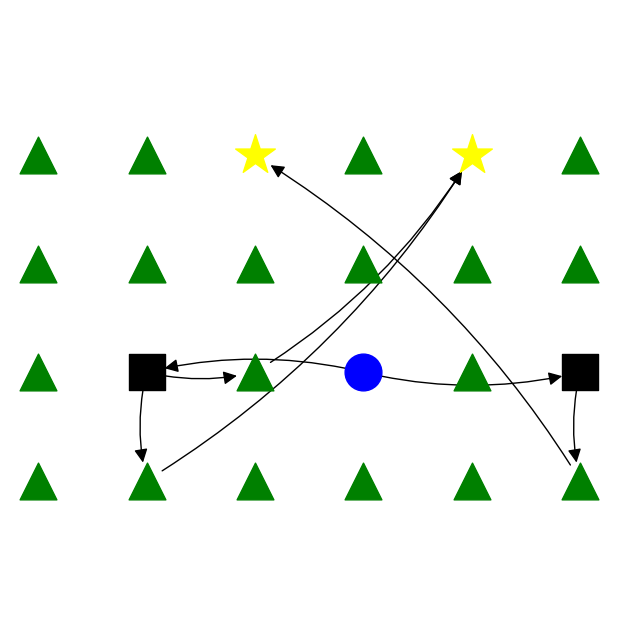

In [40]:
G.add_edges_from(arestas)

x_nodes = set()

for node in visitados:

    if node not in estrelas and G.out_degree(node) == 0:
        x_nodes.add(node)

labels_x = {
    node: "X"
    for node in x_nodes
}

plt.figure(figsize=(8, 8))

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=20,
    node_size=700,
    connectionstyle="arc3,rad=0.12"
)

formatos = {
    "C": ("o", "blue"),
    "Q": ("s", "black"),
    "T": ("^", "green")
}

for tipo, (forma, cor) in formatos.items():

    nodes = [
        node
        for node in G.nodes
        if G.nodes[node]["tipo"] == tipo
        and node not in estrelas
    ]

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nodes,
        node_shape=forma,
        node_color=cor,
        node_size=700
    )

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(estrelas),
    node_shape="*",
    node_color="yellow",
    node_size=900
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels_x,
    font_color="red",
    font_size=14,
    font_weight="bold"
)

plt.axis("off")
plt.axis("equal")
plt.show()